# Order Flow Imbalance et Price Impact — S&P 500 (SPY)

Implémentation du modèle de **Cont, Kukanov & Stoikov (2014)**.

L'idée centrale : le déséquilibre entre la pression d'achat et de vente au meilleur prix prédit les variations de prix à court terme.

$$\Delta p_t = \beta \cdot OFI_t + \epsilon_t$$

| Paramètre | Interprétation |
|-----------|----------------|
| $\beta$ | sensibilité du prix à la pression d'ordre — Kyle's lambda |
| $1/\beta$ | **market depth** — volume nécessaire pour déplacer le prix d'un tick |
| $R^2$ | fraction des mouvements de prix expliqués par l'OFI |

**Données** : quotes tick-by-tick de SPY via l'API Alpaca (gratuite).  
SPY est un proxy liquide du S&P 500 en régime large-tick — spread = 1 tick quasi-systématiquement.

## 0. Dépendances

```bash
pip install alpaca-py statsmodels pandas numpy matplotlib
```

Créer un compte sur [alpaca.markets](https://alpaca.markets) pour obtenir les clés API (plan gratuit suffisant).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm

from datetime import datetime
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockQuotesRequest

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120

## 1. Récupération des données

On récupère les quotes tick-by-tick de SPY sur une journée de trading.  
Chaque quote contient : `timestamp`, `bid_price`, `bid_size`, `ask_price`, `ask_size`.

Le feed `sip` (Securities Information Processor) agrège toutes les bourses US — c'est la source de référence.

In [2]:
API_KEY    = os.environ["ALPACA_API_KEY"]
SECRET_KEY = os.environ["ALPACA_SECRET_KEY"]

client = StockHistoricalDataClient(API_KEY, SECRET_KEY)

In [3]:
request = StockQuotesRequest(
    symbol_or_symbols="SPY",
    start=datetime(2024, 3, 1, 9, 30),
    end=datetime(2024, 3, 1, 16, 0),
    feed="sip",
)

raw = client.get_stock_quotes(request)

# .df retourne un DataFrame multi-index (symbol, timestamp)
# .loc["SPY"] extrait les lignes du ticker voulu
quotes = raw.df.loc["SPY"][["bid_price", "bid_size", "ask_price", "ask_size"]].copy()
quotes.index = pd.to_datetime(quotes.index).tz_convert("America/New_York")

print(f"{len(quotes):,} quotes chargées")
quotes.head()

1,382,322 quotes chargées


,bid_price,bid_size,ask_price,ask_size
timestamp,,,,
2024-03-01 04:30:00.008012-05:00,509.53,4.0,509.57,4.0
2024-03-01 04:30:04.770982-05:00,509.53,3.0,509.57,4.0
2024-03-01 04:30:07.801949-05:00,509.53,3.0,509.55,1.0
2024-03-01 04:30:12.036215-05:00,509.52,4.0,509.55,1.0
2024-03-01 04:30:12.036215-05:00,509.52,4.0,509.55,4.0


## 2. Calcul de l'OFI

### 2.1 Rééchantillonnage

On rééchantillonne à `FREQ` pour obtenir un snapshot du meilleur bid/ask à chaque intervalle.  
On prend le **dernier** tick de chaque intervalle (état du book en fin de période).

### 2.2 Formule

$$OFI_t = \Delta B_t - \Delta A_t$$

$$
\Delta B_t = q^b_t \cdot \mathbf{1}_{p^b_t \geq p^b_{t-1}} - q^b_{t-1} \cdot \mathbf{1}_{p^b_t \leq p^b_{t-1}}
$$

$$
\Delta A_t = q^a_t \cdot \mathbf{1}_{p^a_t \leq p^a_{t-1}} - q^a_{t-1} \cdot \mathbf{1}_{p^a_t \geq p^a_{t-1}}
$$

**Intuition** : si le bid monte (ou grossit) et l'ask baisse (ou grossit), la pression est haussière — OFI > 0.

In [4]:
FREQ = "1min"

df = quotes.resample(FREQ).last().dropna()

print(f"{len(df)} barres de {FREQ}")

390 barres de 1min


In [5]:
def compute_ofi(df: pd.DataFrame) -> pd.DataFrame:
    bp = df["bid_price"]
    bq = df["bid_size"]
    ap = df["ask_price"]
    aq = df["ask_size"]

    delta_b = (
        bq   * (bp >= bp.shift(1)).astype(int)
        - bq.shift(1) * (bp <= bp.shift(1)).astype(int)
    )

    delta_a = (
        aq   * (ap <= ap.shift(1)).astype(int)
        - aq.shift(1) * (ap >= ap.shift(1)).astype(int)
    )

    out = df.copy()
    out["ofi"]       = delta_b - delta_a
    out["mid"]       = (bp + ap) / 2
    out["delta_mid"] = out["mid"].diff()

    return out.dropna()


df = compute_ofi(df)
df[["mid", "ofi", "delta_mid"]].describe().round(4)

,mid,ofi,delta_mid
count,389.0000,389.0000,389.0000
mean,508.7738,1.3085,0.0034
std,0.7128,16.2886,0.0960
min,507.3750,-54.0000,-0.4400
25%,508.3050,-9.0000,-0.0450
50%,508.6650,4.0000,0.0100
75%,509.1050,11.0000,0.0500
max,510.6850,64.0000,0.4950


## 3. Régression OFI → ΔMid

On estime par **OLS** :

$$\Delta p_t = \alpha + \beta \cdot OFI_t + \epsilon_t$$

- $\alpha$ doit être proche de 0 (pas de drift systématique sur une journée)
- $\beta$ > 0 : une pression acheteuse nette déplace le prix vers le haut
- $R^2$ attendu entre 0.30 et 0.70 à 1 minute sur SPY

In [6]:
X = sm.add_constant(df["ofi"])
y = df["delta_mid"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              delta_mid   R-squared:                       0.372
Model:                            OLS   Adj. R-squared:                  0.371
Method:                 Least Squares   F-statistic:                     229.4
Date:                Fri, 08 May 2026   Prob (F-statistic):           4.99e-41
Time:                        20:46:23   Log-Likelihood:                 450.54
No. Observations:                 389   AIC:                            -897.1
Df Residuals:                     387   BIC:                            -889.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0013      0.004     -0.345      0.7

# Analyse des résultats — Régression OFI → ΔMid (SPY, 1 min, 01/03/2024)

## Modèle estimé

$$\Delta p_t = \alpha + \beta \cdot OFI_t + \epsilon_t$$

---

## Qualité globale du modèle

| Métrique | Valeur | Interprétation |
|----------|--------|----------------|
| R² | 0.372 | 37% de la variance des prix expliquée par l'OFI seul |
| F-statistic | 229.4 | Rejet net de l'hypothèse nulle — le modèle est globalement significatif |
| N | 389 | 389 barres de 1 minute sur la session 9h30–16h00 |

Le R² de 0.37 est conforme aux estimations de la littérature. Cont, Kukanov & Stoikov (2014) rapportent des valeurs entre 0.30 et 0.60 sur des actions liquides à cette fréquence. Ce niveau confirme que l'OFI est le principal déterminant des variations de prix à court terme sur SPY — un résultat attendu en régime large-tick, où la liquidité est concentrée au meilleur prix.

---

## Coefficients

### Constante — α = -0.0013 (p = 0.73)

Non significatif. Il n'existe pas de drift systématique du mid-price sur la journée, ce qui est cohérent avec l'hypothèse d'efficience statistique à cette fréquence.

### OFI — β = 0.0036 (t = 15.1, p ≈ 0)

Le coefficient est hautement significatif et positif : une pression acheteuse nette déplace le mid vers le haut, une pression vendeuse vers le bas.

**Interprétation économique :**

$$\text{Market Depth} = \frac{1}{\beta} \approx 278 \text{ actions par tick}$$

Il faut un déséquilibre net d'environ 278 actions au meilleur prix pour déplacer le mid d'un tick. Ce chiffre est une estimation empirique de la **Kyle's lambda** à partir du LOB — il mesure le coût en liquidité d'une pression directionnelle unitaire.

---

## Diagnostic des résidus

### Queues épaisses — Kurtosis = 10.17, JB p ≈ 0

Les résidus sont fortement leptokurtiques. C'est la signature empirique attendue : les distributions de returns financiers suivent une loi de Student avec ν ≈ 4, et non une loi normale. Conséquence directe : les intervalles de confiance OLS standard sont sous-estimés. Pour corriger ce biais sans changer β ni R², il suffit d'utiliser des erreurs robustes :

```python
model = sm.OLS(y, X).fit(cov_type="HC3")
```

### Autocorrélation des résidus — Durbin-Watson = 2.305

Une valeur de 2 indique l'absence d'autocorrélation. La valeur de 2.305 signale une légère autocorrélation négative résiduelle — après un déplacement de prix, il existe une faible tendance à la mean-reversion immédiate. Ce phénomène est cohérent avec la dynamique de queue en régime large-tick : un market order qui consomme le meilleur prix déclenche souvent un repositionnement rapide des market makers, qui reconstituent leur quote au même niveau.

---

## Limites du modèle

**Une seule journée.** Les résultats portent sur le 01/03/2024. Le β et le R² varient selon les conditions de marché — notamment autour des annonces macroéconomiques (FOMC, NFP) où l'adverse selection est structurellement plus élevée et le book plus mince.

**Linéarité.** Le modèle suppose un impact linéaire de l'OFI. Des travaux récents (Cont & Kukanov, 2014 ; Taranto et al., 2018) montrent que l'impact est concave pour les grands déséquilibres — le modèle linéaire sous-estime l'impact aux extrêmes.

**SPY vs ES futures.** SPY est un ETF sur actions, soumis au régime de trading des marchés actions US. Les ES futures (CME) ont une microstructure légèrement différente : pro-rata partiel, participants différents, pas de fragmentation inter-venues. Le β estimé ici n'est pas directement transposable aux futures.

---

## Références

- Cont, Kukanov & Stoikov — *The Price Impact of Order Book Events*, Review of Finance (2014)
- Kyle — *Continuous Auctions and Insider Trading*, Econometrica (1985)
- Cont — *Empirical Properties of Asset Returns: Stylised Facts*, Quantitative Finance (2001)

In [7]:
beta  = model.params["ofi"]
r2    = model.rsquared
depth = 1 / beta if beta > 0 else float("nan")

print(f"Beta  (Kyle lambda)  : {beta:.6f}  USD / contrat")
print(f"Depth (1 / beta)     : {depth:,.1f}  contrats par tick")
print(f"R²                   : {r2:.4f}")

Beta  (Kyle lambda)  : 0.003597  USD / contrat
Depth (1 / beta)     : 278.0  contrats par tick
R²                   : 0.3722


## 4. Visualisation

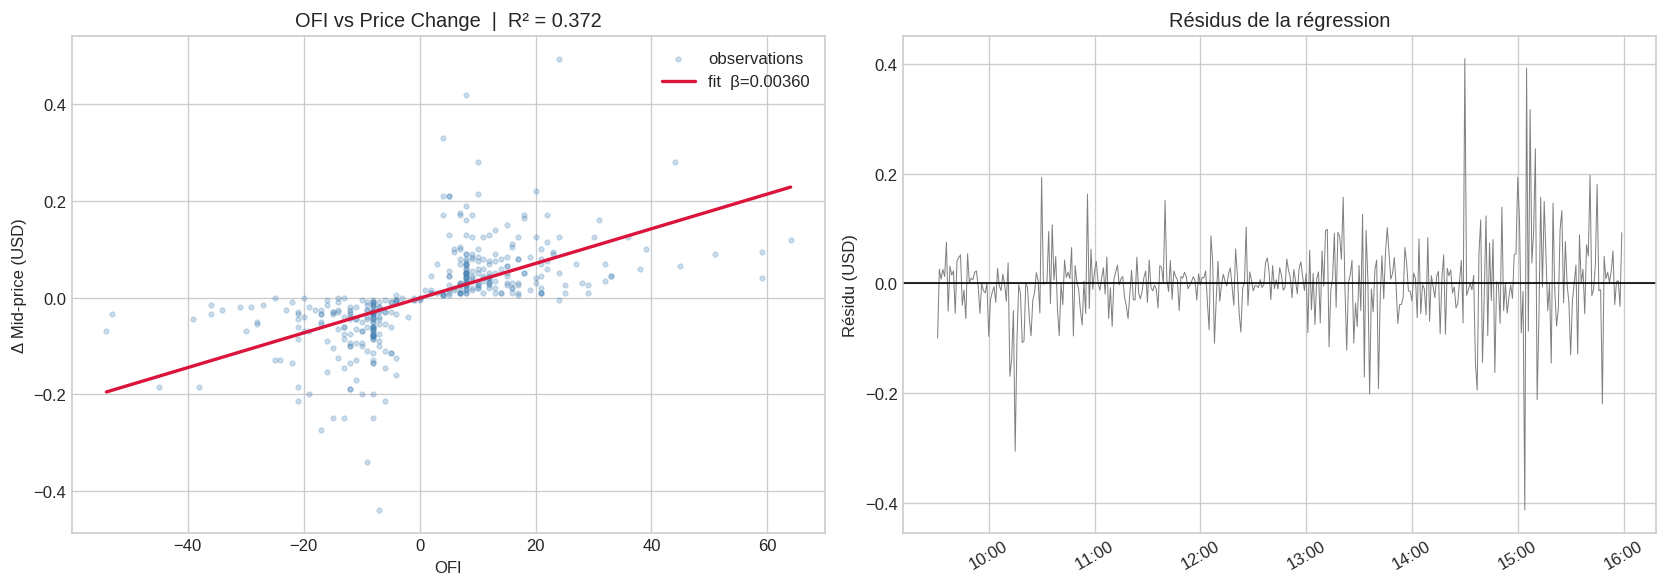

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Scatter OFI vs delta_mid ---
ax = axes[0]
ax.scatter(df["ofi"], df["delta_mid"], alpha=0.25, s=8, color="steelblue", label="observations")
x_range = np.linspace(df["ofi"].min(), df["ofi"].max(), 300)
ax.plot(x_range, model.params["const"] + beta * x_range, color="crimson", lw=2, label=f"fit  β={beta:.5f}")
ax.set_xlabel("OFI")
ax.set_ylabel("Δ Mid-price (USD)")
ax.set_title(f"OFI vs Price Change  |  R² = {r2:.3f}")
ax.legend()

# --- Résidus dans le temps ---
ax = axes[1]
ax.plot(df.index, model.resid, color="gray", lw=0.6)
ax.axhline(0, color="black", lw=1)
ax.set_title("Résidus de la régression")
ax.set_ylabel("Résidu (USD)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.show()

## 5. Beta intraday — évolution de la profondeur de marché

On estime $\beta$ sur des **fenêtres glissantes** de `WINDOW` minutes.

Prédiction théorique :
- **Beta élevé à l'ouverture** : adverse selection forte, book mince, peu de market makers présents
- **Beta décroît** au fil de la journée : le book s'épaissit, la profondeur augmente
- **Beta remonte à la clôture** : réduction d'inventaire, book qui se vide avant 16h

Ce pattern correspond au **profil en J inversé** de la profondeur observé empiriquement.

In [9]:
WINDOW = 30  # barres de FREQ

betas, r2s, times = [], [], []

for i in range(WINDOW, len(df)):
    w = df.iloc[i - WINDOW:i]
    try:
        m = sm.OLS(w["delta_mid"], sm.add_constant(w["ofi"])).fit()
        betas.append(m.params["ofi"])
        r2s.append(m.rsquared)
        times.append(df.index[i])
    except Exception:
        pass

rolling = pd.DataFrame({"beta": betas, "r2": r2s}, index=times)

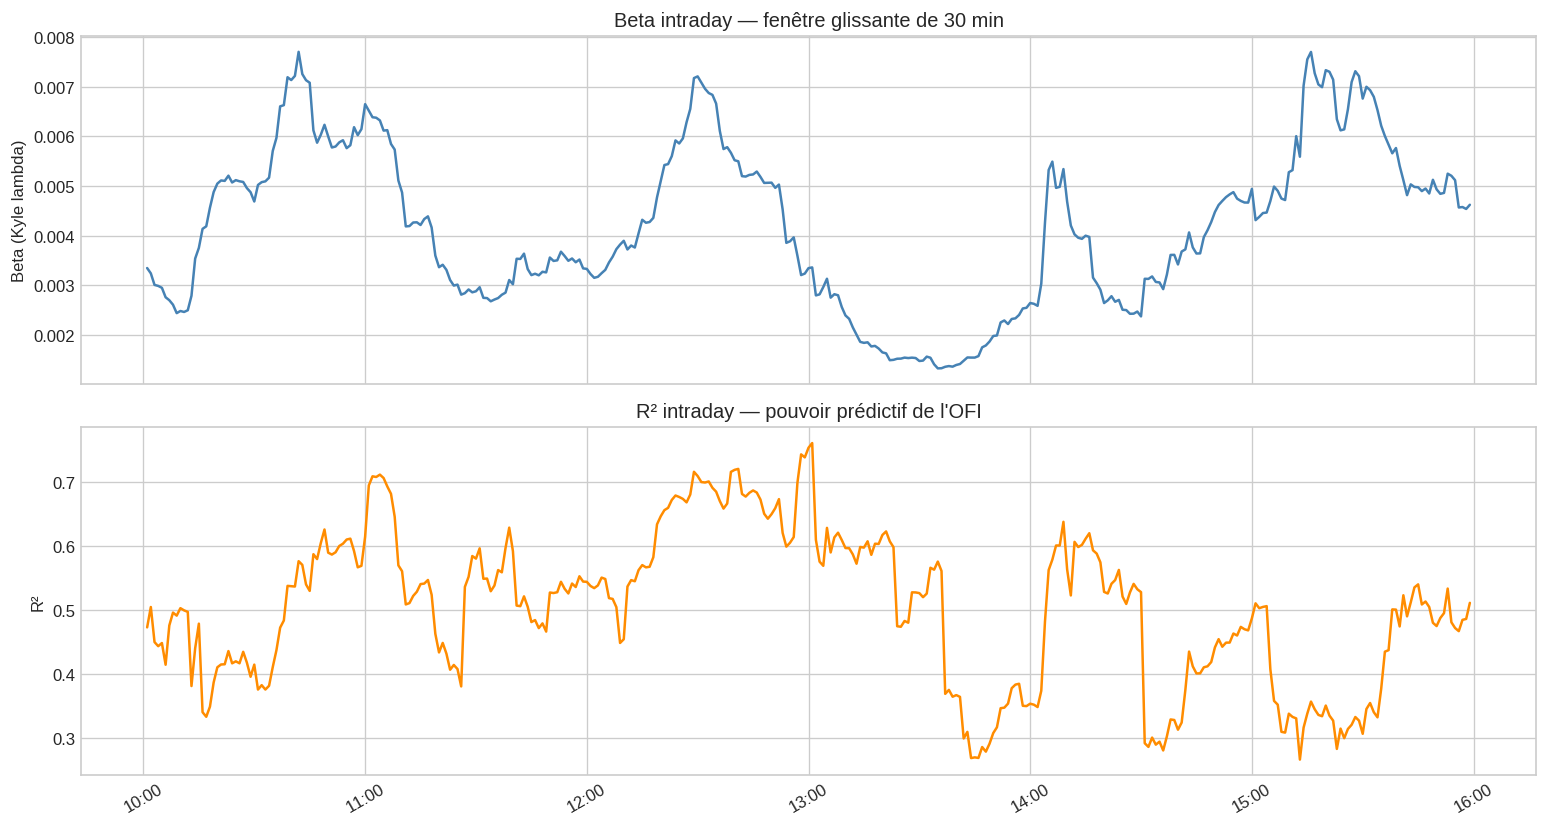

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

ax = axes[0]
ax.plot(rolling.index, rolling["beta"], color="steelblue", lw=1.5)
ax.set_ylabel("Beta (Kyle lambda)")
ax.set_title(f"Beta intraday — fenêtre glissante de {WINDOW} min")

ax = axes[1]
ax.plot(rolling.index, rolling["r2"], color="darkorange", lw=1.5)
ax.set_ylabel("R²")
ax.set_title("R² intraday — pouvoir prédictif de l'OFI")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.show()